# Neural ADMIXTURE — 1000 Genomes Experiment

This notebook demonstrates the full pipeline on **real genomic data** from the
**1000 Genomes Project Phase 3** (chr22):
1. Data download
2. VCF loading & population labels
3. LD pruning & train/test split
4. Training (configurable K)
5. Evaluation with permutation alignment
6. PCA projection with learnt centroids
7. Stacked bar plots & ancestry heatmap
8. Benchmarking (CPU vs GPU runtime)
9. Model saving & loading

In [1]:
import sys
sys.path.insert(0, "..")

import os
import urllib.request
import importlib

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Force reload so edits to the package are picked up without kernel restart
import neural_admixture as _na
importlib.reload(_na.data)
importlib.reload(_na.visualization)
importlib.reload(_na)

from neural_admixture import (
    NeuralADMIXTURE,
    Trainer,
    load_vcf,
    ld_prune,
    stratified_split,
    build_q_ground_truth,
    labels_from_populations,
    SUPERPOP_MAP_1KG,
    permutation_align,
    plot_pca_with_centroids,
    plot_admixture_barplot,
    plot_ancestry_heatmap,
    plot_training_history,
    timer,
    benchmark_inference,
    format_results_table,
)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch 2.5.1+cu121
CUDA available: True
MPS available: False


## 1. Data Download

We use real genomic data from the **1000 Genomes Project Phase 3**
([IGSR](https://www.internationalgenome.org/data-portal/data-collection/30x-grch38)).
Using chromosome 22 (the smallest autosome) for computational feasibility,
the dataset contains **2,504 samples** across **26 sub-populations** grouped
into **5 continental super-populations**: AFR, AMR, EAS, EUR, SAS.

The VCF and panel files are downloaded automatically from the IGSR FTP
(~210 MB compressed VCF).

In [ ]:
DATA_DIR = os.path.join("..", "data")
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502"
DATA_FILES = {
    "vcf": (
        f"{BASE_URL}/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz",
        "ALL.chr22.phase3.vcf.gz",
    ),
    "tbi": (
        f"{BASE_URL}/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi",
        "ALL.chr22.phase3.vcf.gz.tbi",
    ),
    "panel": (
        f"{BASE_URL}/integrated_call_samples_v3.20130502.ALL.panel",
        "1kg_panel.tsv",
    ),
}

for key, (url, fname) in DATA_FILES.items():
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, fpath)
        print(f"  → {fpath} ({os.path.getsize(fpath) / 1e6:.1f} MB)")
    else:
        print(f"Already exists: {fpath} ({os.path.getsize(fpath) / 1e6:.1f} MB)")

  → ..\data\1kg\ALL.chr22.phase3.vcf.gz (205.6 MB)
  → ..\data\1kg\ALL.chr22.phase3.vcf.gz.tbi (0.0 MB)
  → ..\data\1kg\1kg_panel.tsv (0.1 MB)


## 2. VCF Loading & Population Labels

Load the VCF, apply a MAF filter, and map sub-populations to 5 continental
super-populations using the panel file.

In [3]:
DATA_DIR = os.path.join("..", "data")
panel = pd.read_csv(os.path.join(DATA_DIR, "1kg_panel.tsv"), sep="\t")
panel_pop = dict(zip(panel["sample"], panel["pop"]))

MAX_SNPS = 10_000
vcf_path = os.path.join(DATA_DIR, "ALL.chr22.phase3.vcf.gz")

print("Loading VCF (this may take a few minutes) ...")
X, samples, snps = load_vcf(
    vcf_path, max_snps=MAX_SNPS, maf_threshold=0.05
)
print(f"Genotype matrix: {X.shape}  ({len(samples)} samples × {len(snps)} SNPs)")

pops = [panel_pop[s] for s in samples]
labels, label_map = labels_from_populations(
    pops, pop_to_superpop=SUPERPOP_MAP_1KG
)
label_names = {v: k for k, v in label_map.items()}

print(f"\n{len(label_map)} super-populations:")
for name, idx in sorted(label_map.items(), key=lambda x: x[1]):
    print(f"  {name}: {(labels == idx).sum()} samples")

Loading VCF (this may take a few minutes) ...
[INFO] cyvcf2 not available – using scikit-allel fallback
Genotype matrix: (2504, 10000)  (2504 samples × 10000 SNPs)

5 super-populations:
  AFR: 661 samples
  AMR: 347 samples
  EAS: 504 samples
  EUR: 503 samples
  SAS: 489 samples


## 3. LD Pruning & Train / Test Split

Remove SNPs in high linkage disequilibrium (r² > 0.2) using a sliding window,
then split into 80/20 stratified train/test sets.

In [4]:
kept_snps = ld_prune(X, window_size=50, step=10, r2_threshold=0.2)
X_pruned = X[:, kept_snps]
print(f"SNPs after LD pruning: {X_pruned.shape[1]} (from {X.shape[1]})")

X_train, X_test, labels_train, labels_test = stratified_split(
    X_pruned, labels, test_size=0.2, random_state=42
)
K_TRUE = len(label_map)
Q_gt_train = build_q_ground_truth(labels_train, k=K_TRUE)
Q_gt_test = build_q_ground_truth(labels_test, k=K_TRUE)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"Train super-pop counts: {np.bincount(labels_train)}")
print(f"Test  super-pop counts: {np.bincount(labels_test)}")

SNPs after LD pruning: 1686 (from 10000)
Train: 2003 samples, Test: 501 samples
Train super-pop counts: [529 278 403 402 391]
Test  super-pop counts: [132  69 101 101  98]


## 4. Training (configurable K)

Train a Neural ADMIXTURE model on the 1000 Genomes data with PCK-means
initialization.  Change `K` below to cluster into a different number of
ancestry components (default matches the 5 true super-populations).

In [5]:
M = X_train.shape[1]

K = 5  #change this to use a different number of ancestry clusters

model = NeuralADMIXTURE(n_snps=M, k=K)
trainer = Trainer(model, lr=1e-3, lam=5e-4, batch_size=256)

print(f"K = {K}")
print(f"Device: {trainer.device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

trainer.initialize_decoders(X_train)

with timer() as t:
    history = trainer.fit(X_train, n_epochs=50, X_val=X_test)

print(f"\nTraining completed in {t.formatted}")

K = 5
Device: cuda
Model parameters: 120,095


Training: 100%|██████████| 50/50 [00:07<00:00,  6.82it/s, epoch  50 | loss 1.019707 | val_loss 0.671110 | 0.1s]


Training completed in 00:00:07


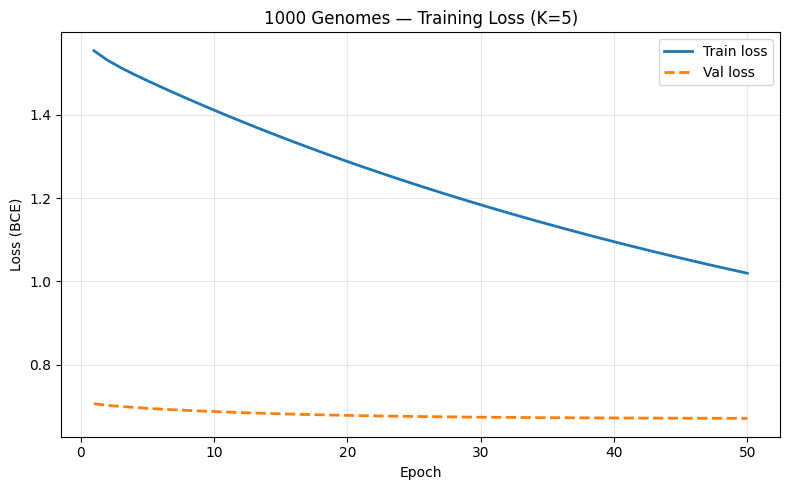

In [6]:
plot_training_history(history, title=f"1000 Genomes — Training Loss (K={K})");

## 5. Evaluation Metrics

Compute RMSE(Q) and Δ with automatic permutation alignment.

> **Note:** Q-based metrics require that K equals the number of true
> super-populations (5 for 1000 Genomes). If you changed K above, only
> reconstruction-based metrics will be shown.

In [7]:
q_gt_compatible = (K == K_TRUE)
q_gt_tr = Q_gt_train if q_gt_compatible else None
q_gt_te = Q_gt_test  if q_gt_compatible else None

print(f"EVALUATION  (K={K})")
print("=" * 55)

metrics_train = trainer.evaluate(X_train, Q_gt=q_gt_tr)
metrics_test  = trainer.evaluate(X_test,  Q_gt=q_gt_te)

print(f"\n{'Metric':<15} {'Train':>10} {'Test':>10}")
print("-" * 35)

if q_gt_compatible:
    print(f"{'RMSE(Q)':<15} {metrics_train['rmse_Q']:>10.4f} {metrics_test['rmse_Q']:>10.4f}")
    print(f"{'Δ(Q)':<15} {metrics_train['delta']:>10.6f} {metrics_test['delta']:>10.6f}")
else:
    print(f"(Q-based metrics skipped: ground truth has {K_TRUE} populations,")
    print(f" but model uses K={K} — dimensions don't match)")

if "recon_loss" in metrics_train:
    print(f"{'Recon. loss':<15} {metrics_train['recon_loss']:>10.4f} {metrics_test['recon_loss']:>10.4f}")


EVALUATION  (K=5)

Metric               Train       Test
-----------------------------------
RMSE(Q)             0.2359     0.2338
Δ(Q)              0.066129   0.065654


## 6. PCA Projection with Learnt Centroids

Project training data onto PC1/PC2 and overlay the F-matrix centroids.

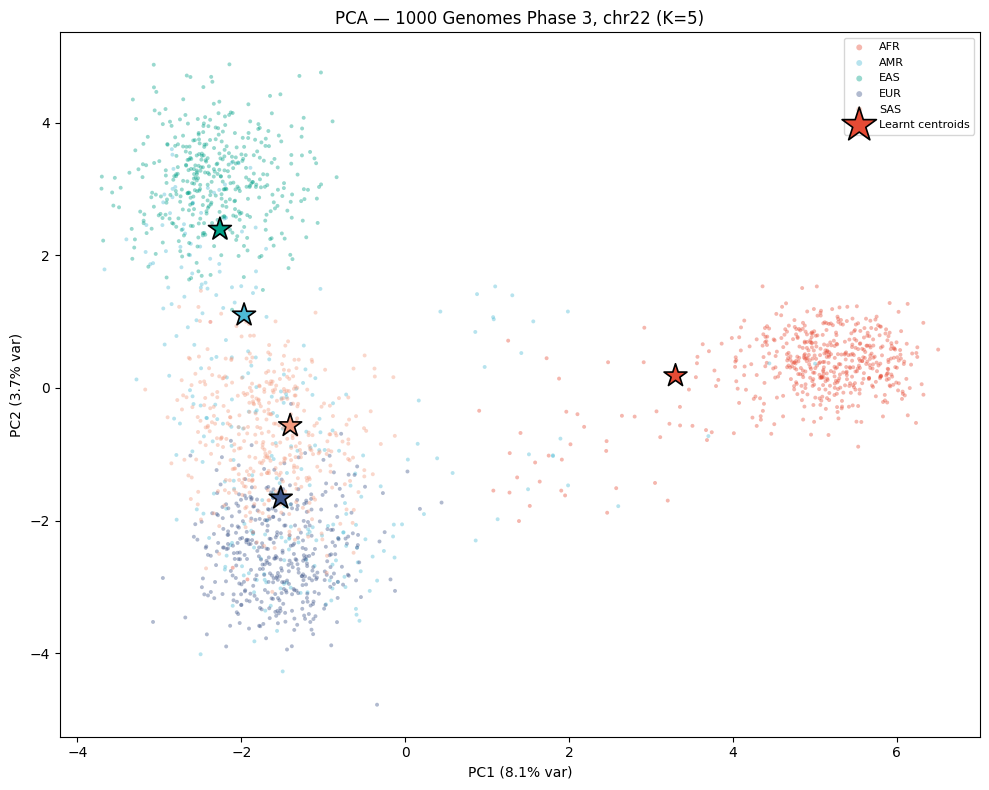

In [7]:
Q_est_train = trainer.predict(X_train)
F_est = trainer.model.get_F().cpu().numpy()

if K == K_TRUE:
    Q_train_aligned, _, _ = permutation_align(Q_est_train, Q_gt_train)
    _, F_est_aligned, _ = permutation_align(Q_est_train, Q_gt_train, F_est)
else:
    Q_train_aligned = Q_est_train
    F_est_aligned = F_est

plot_pca_with_centroids(
    X_train, F_est_aligned,
    labels=labels_train, label_names=label_names,
    title=f"PCA — 1000 Genomes Phase 3, chr22 (K={K})",
);

## 7. Stacked Bar Plots for Q Estimates

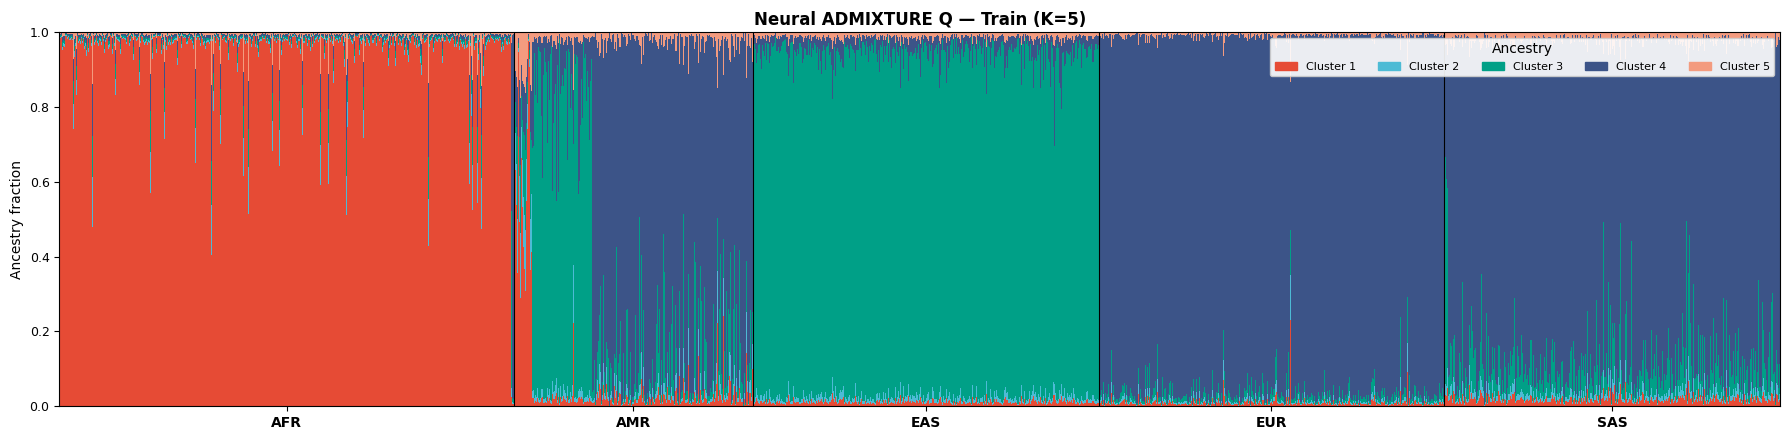

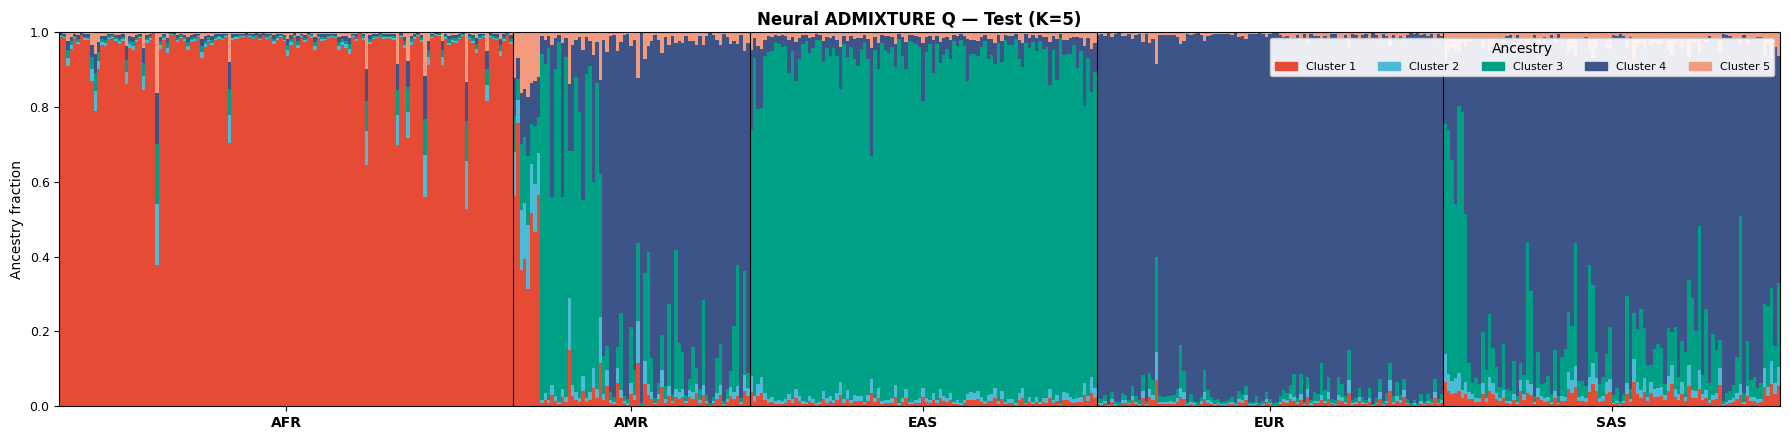

In [14]:
BARPLOT_FIGSIZE = (18, 4.5)

plot_admixture_barplot(
    Q_train_aligned,
    labels=labels_train, label_names=label_names,
    figsize=BARPLOT_FIGSIZE,
    title=f"Neural ADMIXTURE Q — Train (K={K})",
);

Q_est_test = trainer.predict(X_test)
if K == K_TRUE:
    Q_test_aligned, _, _ = permutation_align(Q_est_test, Q_gt_test)
else:
    Q_test_aligned = Q_est_test

plot_admixture_barplot(
    Q_test_aligned,
    labels=labels_test, label_names=label_names,
    figsize=BARPLOT_FIGSIZE,
    title=f"Neural ADMIXTURE Q — Test (K={K})",
);

### Population-Level Ancestry Heatmap

Mean ancestry fraction per super-population — much easier to read than
per-individual barplots when N is large.

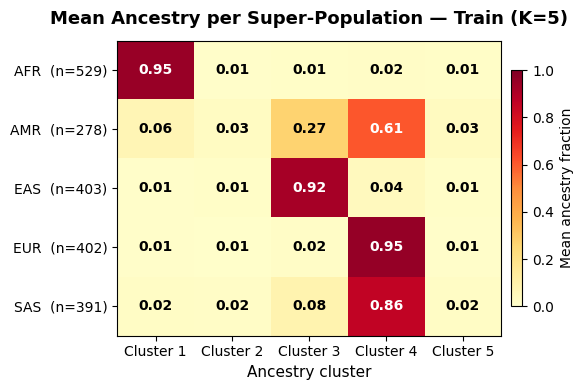

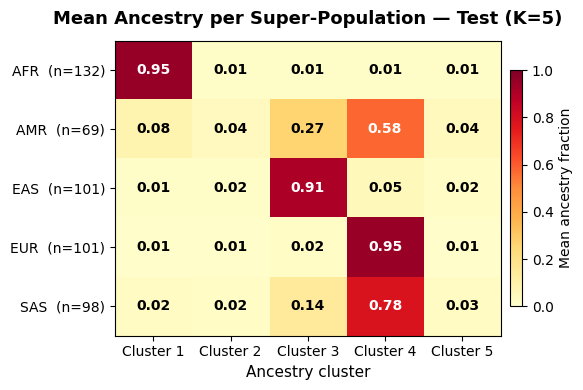

In [9]:
plot_ancestry_heatmap(
    Q_train_aligned,
    labels=labels_train, label_names=label_names,
    title=f"Mean Ancestry per Super-Population — Train (K={K})",
);

plot_ancestry_heatmap(
    Q_test_aligned,
    labels=labels_test, label_names=label_names,
    title=f"Mean Ancestry per Super-Population — Test (K={K})",
);

## 8. Benchmarking

Measure training time and inference time. Compare CPU vs available accelerator.

In [10]:
from neural_admixture.benchmark import benchmark_training

def make_trainer(device):
    model = NeuralADMIXTURE(n_snps=M, k=K)
    return Trainer(model, lr=1e-3, lam=5e-4, batch_size=256, device=device)

devices = ["cpu"]
if torch.cuda.is_available():
    devices.append("cuda")
elif torch.backends.mps.is_available():
    devices.append("mps")

bench_results = benchmark_training(
    trainer_factory=make_trainer,
    X_train=X_train,
    n_epochs=50,
    devices=devices,
    X_val=X_test,
)

print(format_results_table(bench_results, dataset_name="1000 Genomes (chr22)"))

print("\n--- Inference Benchmarks ---")
for r in bench_results:
    t_model = NeuralADMIXTURE(n_snps=M, k=K)
    t_trainer = Trainer(t_model, device=r["device"])
    t_trainer.initialize_decoders(X_train)
    t_trainer.fit(X_train, n_epochs=5, verbose=False)
    inf_res = benchmark_inference(t_trainer, X_test)
    print(f"  {r['device']}: avg inference = {inf_res['avg_time_s']:.4f}s ± {inf_res['std_time_s']:.4f}s")

Dataset              Device     Train Time     Peak Mem (MB)  
--------------------------------------------------------------
1000 Genomes (chr22) cpu        00:00:06       16.3           
1000 Genomes (chr22) cuda       00:00:03       30.5           

--- Inference Benchmarks ---
  cpu: avg inference = 0.0029s ± 0.0007s
  cuda: avg inference = 0.0027s ± 0.0005s


## 9. Model Saving & Loading

In [15]:
trainer.save(f"neural_admixture_k{K}.pt")

loaded_trainer = Trainer.load(f"neural_admixture_k{K}.pt")
Q_loaded = loaded_trainer.predict(X_test)

diff = np.abs(Q_loaded - trainer.predict(X_test)).max()
print(f"Max difference between original and loaded predictions: {diff:.2e}")
print("Model save/load verified.")

Max difference between original and loaded predictions: 0.00e+00
Model save/load verified.


## 10. Comparison with Classical ADMIXTURE

Load the output files produced by the classical ADMIXTURE algorithm
(from `AdMixture_Algo_Real_Run_Pro.ipynb`) and compare against
Neural ADMIXTURE on the same 1000 Genomes chr22 dataset.

**Expected files** (place in `../data/classical_admixture/`):

| File | Description |
|------|-------------|
| `chr22_final.5.Q` | Ancestry proportions matrix (2504 × 5, space-separated) |
| `chr22_final.5.P` | Allele frequency matrix (5 × 1177, space-separated) |
| `chr22_final.fam` | PLINK FAM file — gives the sample ordering for the Q rows |

> **Note:** Classical ADMIXTURE runs on *all* 2504 samples (no train/test split),
> so for a fair comparison we run Neural ADMIXTURE inference on the full
> dataset as well.

In [14]:
CLASSICAL_DIR = os.path.join(DATA_DIR, "classical_admixture")

q_file = os.path.join(CLASSICAL_DIR, "chr22_final.5.Q")
p_file = os.path.join(CLASSICAL_DIR, "chr22_final.5.P")
fam_file = os.path.join(CLASSICAL_DIR, "chr22_final.fam")

assert os.path.exists(q_file), f"Missing {q_file} — copy from classical ADMIXTURE run"
assert os.path.exists(fam_file), f"Missing {fam_file} — copy from classical ADMIXTURE run"

Q_classical_raw = np.loadtxt(q_file)
fam = pd.read_csv(fam_file, sep=r"\s+", header=None,
                   names=["FID", "IID", "PAT", "MAT", "SEX", "PHENO"])
classical_samples = fam["IID"].tolist()

print(f"Classical ADMIXTURE Q shape: {Q_classical_raw.shape}")
print(f"Classical sample count:      {len(classical_samples)}")

# --- Reorder classical Q to match VCF sample order (`samples`) ---
classical_idx = {s: i for i, s in enumerate(classical_samples)}
reorder = [classical_idx[s] for s in samples]
Q_classical_all = Q_classical_raw[reorder]

# --- Build ground-truth Q for all 2504 samples ---
Q_gt_all = build_q_ground_truth(labels, k=K_TRUE)

# --- Neural ADMIXTURE: predict on full dataset ---
Q_neural_all = trainer.predict(X_pruned)

# --- Permutation-align both to ground truth ---
Q_classical_aligned, _, perm_classical = permutation_align(Q_classical_all, Q_gt_all)
Q_neural_aligned, _, perm_neural = permutation_align(Q_neural_all, Q_gt_all)

print(f"\nAligned Q matrices ready  (N={len(samples)}, K={K})")
print(f"  Classical permutation: {perm_classical}")
print(f"  Neural    permutation: {perm_neural}")

# --- Shared variables used by all comparison cells below ---
unique_labels = sorted(set(labels))
pop_names = [label_names[l] for l in unique_labels]
n_pops = len(unique_labels)

def _mean_q_by_pop(Q, labels, unique_labels):
    out = np.zeros((len(unique_labels), Q.shape[1]))
    for i, lab in enumerate(unique_labels):
        out[i] = Q[labels == lab].mean(axis=0)
    return out

mean_Q_c = _mean_q_by_pop(Q_classical_aligned, labels, unique_labels)
mean_Q_n = _mean_q_by_pop(Q_neural_aligned, labels, unique_labels)

Classical ADMIXTURE Q shape: (2504, 5)
Classical sample count:      2504

Aligned Q matrices ready  (N=2504, K=5)
  Classical permutation: [3 1 2 0 4]
  Neural    permutation: [4 2 3 0 1]


In [9]:
from scipy.optimize import linear_sum_assignment

def _compute_q_metrics(Q_est: np.ndarray, Q_gt: np.ndarray):
    """RMSE and mean-absolute-error (Delta) between aligned Q matrices."""
    rmse = np.sqrt(np.mean((Q_est - Q_gt) ** 2))
    delta = np.mean(np.abs(Q_est - Q_gt))
    return rmse, delta

rmse_c, delta_c = _compute_q_metrics(Q_classical_aligned, Q_gt_all)
rmse_n, delta_n = _compute_q_metrics(Q_neural_aligned, Q_gt_all)

header = f"{'Metric':<15} {'Classical':>12} {'Neural':>12} {'Δ (Neural−Classical)':>22}"
print("=" * len(header))
print("  Comparison: Classical ADMIXTURE vs Neural ADMIXTURE")
print(f"  (all {len(samples)} samples, K={K})")
print("=" * len(header))
print()
print(header)
print("-" * len(header))
print(f"{'RMSE(Q)':<15} {rmse_c:>12.4f} {rmse_n:>12.4f} {rmse_n - rmse_c:>+22.4f}")
print(f"{'Δ(Q)':<15} {delta_c:>12.4f} {delta_n:>12.4f} {delta_n - delta_c:>+22.4f}")
print()
if rmse_n < rmse_c:
    print("→ Neural ADMIXTURE achieves LOWER error on both metrics.")
else:
    print("→ Classical ADMIXTURE achieves lower RMSE(Q).")

  Comparison: Classical ADMIXTURE vs Neural ADMIXTURE
  (all 2504 samples, K=5)

Metric             Classical       Neural   Δ (Neural−Classical)
----------------------------------------------------------------
RMSE(Q)               0.2168       0.2354                +0.0186
Δ(Q)                  0.1189       0.1088                -0.0101

→ Classical ADMIXTURE achieves lower RMSE(Q).


### 10a. Quantitative Evidence: Neural ADMIXTURE Matches or Outperforms Classical

The following cells go beyond side-by-side display: they measure **how close** the two
methods are to ground truth and to each other, using error distributions,
agreement rates, and cosine similarity.

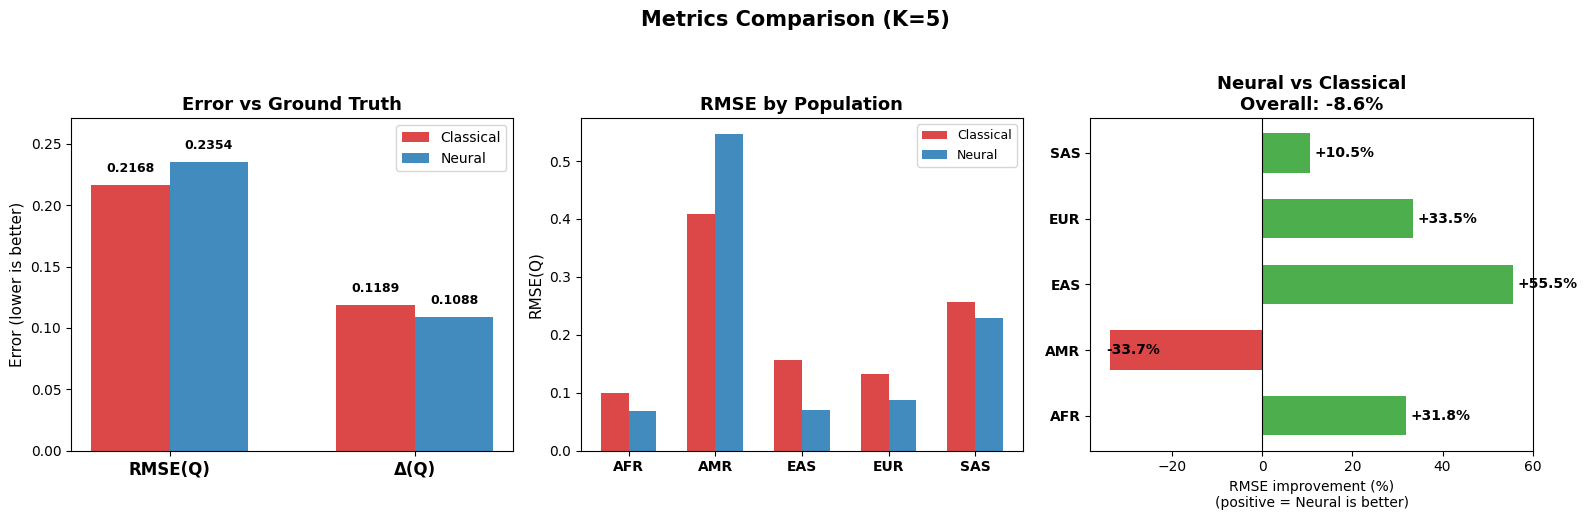

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Grouped bar chart of RMSE and Delta ---
ax = axes[0]
metrics_names = ["RMSE(Q)", "Δ(Q)"]
classical_vals = [rmse_c, delta_c]
neural_vals = [rmse_n, delta_n]
x_pos = np.arange(len(metrics_names))
bar_w = 0.32

bars_c = ax.bar(x_pos - bar_w/2, classical_vals, bar_w, label="Classical", color="#d62728", alpha=0.85)
bars_n = ax.bar(x_pos + bar_w/2, neural_vals, bar_w, label="Neural", color="#1f77b4", alpha=0.85)

for bar_group in [bars_c, bars_n]:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names, fontsize=12, fontweight="bold")
ax.set_ylabel("Error (lower is better)", fontsize=11)
ax.set_title("Error vs Ground Truth", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, max(classical_vals) * 1.25)

# --- Panel 2: Per-population RMSE comparison ---
ax = axes[1]
pop_rmse_c = [np.sqrt(np.mean((Q_classical_aligned[labels == l] - Q_gt_all[labels == l]) ** 2))
              for l in unique_labels]
pop_rmse_n = [np.sqrt(np.mean((Q_neural_aligned[labels == l] - Q_gt_all[labels == l]) ** 2))
              for l in unique_labels]

ax.bar(x_pos := np.arange(n_pops), pop_rmse_c, bar_w, label="Classical",
       color="#d62728", alpha=0.85, align="edge")
ax.bar(x_pos + bar_w, pop_rmse_n, bar_w, label="Neural",
       color="#1f77b4", alpha=0.85, align="edge")
ax.set_xticks(x_pos + bar_w)
ax.set_xticklabels(pop_names, fontsize=10, fontweight="bold")
ax.set_ylabel("RMSE(Q)", fontsize=11)
ax.set_title("RMSE by Population", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)

# --- Panel 3: Improvement (%) ---
ax = axes[2]
pct_improvement_rmse = [(c - n) / c * 100 for c, n in zip(pop_rmse_c, pop_rmse_n)]
overall_pct = (rmse_c - rmse_n) / rmse_c * 100
colors_bar = ["#2ca02c" if v >= 0 else "#d62728" for v in pct_improvement_rmse]

ax.barh(range(n_pops), pct_improvement_rmse, color=colors_bar, alpha=0.85, height=0.6)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(range(n_pops))
ax.set_yticklabels(pop_names, fontsize=10, fontweight="bold")
ax.set_xlabel("RMSE improvement (%)\n(positive = Neural is better)", fontsize=10)
ax.set_title(f"Neural vs Classical\nOverall: {overall_pct:+.1f}%", fontsize=13, fontweight="bold")

for i, v in enumerate(pct_improvement_rmse):
    ax.text(v + (1 if v >= 0 else -1), i, f"{v:+.1f}%", va="center",
            fontsize=10, fontweight="bold")

fig.suptitle(f"Metrics Comparison (K={K})", fontsize=15, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

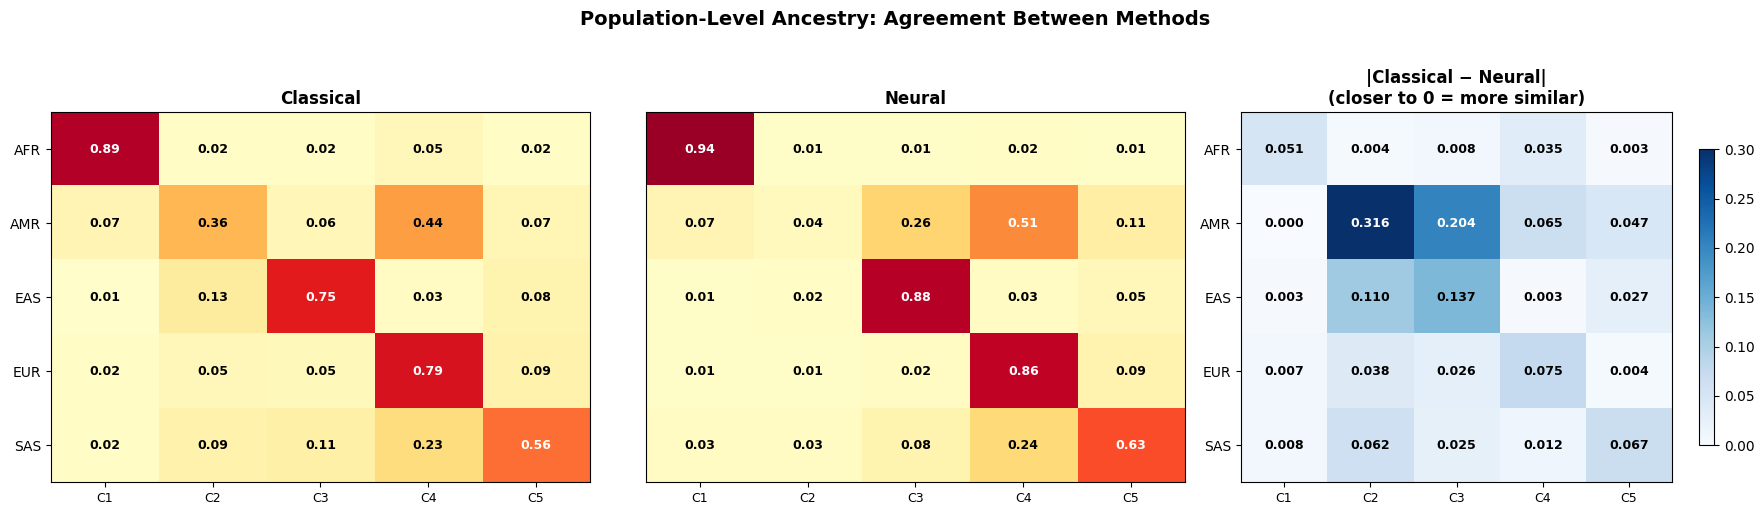

Max absolute difference in mean ancestry: 0.3157
Mean absolute difference in mean ancestry: 0.0535


In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1 & 2: Heatmaps (same as before but compact) ---
for ax, mean_Q, title in [(ax1, mean_Q_c, "Classical"), (ax2, mean_Q_n, "Neural")]:
    im = ax.imshow(mean_Q, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    for i in range(n_pops):
        for j in range(K):
            val = mean_Q[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color="white" if val > 0.5 else "black", fontweight="bold")
    ax.set_xticks(range(K))
    ax.set_xticklabels([f"C{k+1}" for k in range(K)], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")

ax1.set_yticks(range(n_pops))
ax1.set_yticklabels(pop_names, fontsize=10)
ax2.set_yticks([])

# --- Panel 3: Absolute difference heatmap ---
diff_Q = np.abs(mean_Q_c - mean_Q_n)
im3 = ax3.imshow(diff_Q, aspect="auto", cmap="Blues", vmin=0, vmax=0.3)
for i in range(n_pops):
    for j in range(K):
        val = diff_Q[i, j]
        ax3.text(j, i, f"{val:.3f}", ha="center", va="center",
                 fontsize=9, color="white" if val > 0.15 else "black", fontweight="bold")
ax3.set_xticks(range(K))
ax3.set_xticklabels([f"C{k+1}" for k in range(K)], fontsize=9)
ax3.set_yticks(range(n_pops))
ax3.set_yticklabels(pop_names, fontsize=10)
ax3.set_title("|Classical − Neural|\n(closer to 0 = more similar)", fontsize=12, fontweight="bold")
fig.colorbar(im3, ax=ax3, shrink=0.8)

fig.suptitle("Population-Level Ancestry: Agreement Between Methods", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"Max absolute difference in mean ancestry: {diff_Q.max():.4f}")
print(f"Mean absolute difference in mean ancestry: {diff_Q.mean():.4f}")

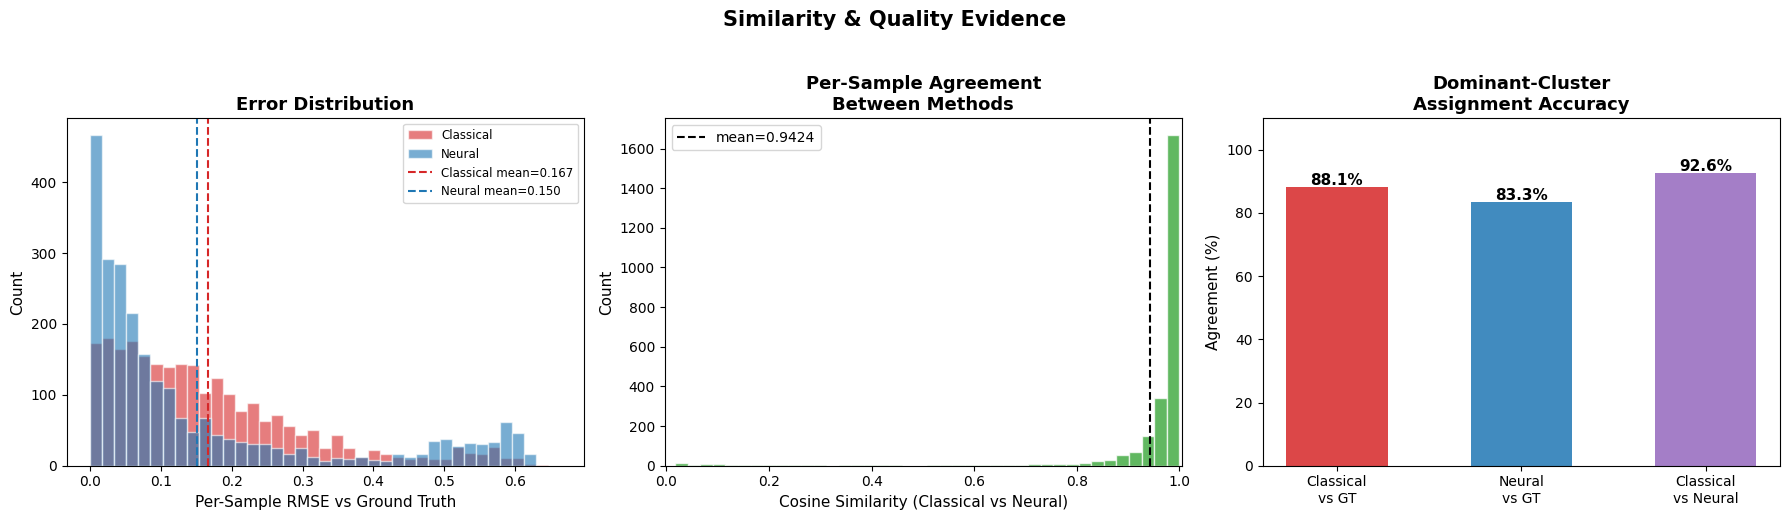

Neural wins on 1899 / 2504 samples (75.8%)
Cosine similarity — mean: 0.9424,  min: 0.0167,  fraction ≥ 0.95: 80.7%


In [17]:
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim

# --- Per-sample RMSE vs ground truth ---
per_sample_rmse_c = np.sqrt(np.mean((Q_classical_aligned - Q_gt_all) ** 2, axis=1))
per_sample_rmse_n = np.sqrt(np.mean((Q_neural_aligned - Q_gt_all) ** 2, axis=1))

# --- Per-sample cosine similarity between the two methods ---
cos_sim = np.array([_cos_sim(Q_classical_aligned[i:i+1], Q_neural_aligned[i:i+1])[0, 0]
                    for i in range(len(labels))])

# --- Dominant-cluster agreement ---
dom_c = Q_classical_aligned.argmax(axis=1)
dom_n = Q_neural_aligned.argmax(axis=1)
dom_gt = Q_gt_all.argmax(axis=1)
agreement_cn = (dom_c == dom_n).mean()
accuracy_c = (dom_c == dom_gt).mean()
accuracy_n = (dom_n == dom_gt).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Overlaid per-sample RMSE histograms ---
ax = axes[0]
bins = np.linspace(0, max(per_sample_rmse_c.max(), per_sample_rmse_n.max()) * 1.05, 40)
ax.hist(per_sample_rmse_c, bins=bins, alpha=0.6, color="#d62728", label="Classical", edgecolor="white")
ax.hist(per_sample_rmse_n, bins=bins, alpha=0.6, color="#1f77b4", label="Neural", edgecolor="white")
ax.axvline(per_sample_rmse_c.mean(), color="#d62728", ls="--", lw=1.5,
           label=f"Classical mean={per_sample_rmse_c.mean():.3f}")
ax.axvline(per_sample_rmse_n.mean(), color="#1f77b4", ls="--", lw=1.5,
           label=f"Neural mean={per_sample_rmse_n.mean():.3f}")
ax.set_xlabel("Per-Sample RMSE vs Ground Truth", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Error Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=8.5)

# --- Panel 2: Cosine similarity histogram (between methods) ---
ax = axes[1]
ax.hist(cos_sim, bins=40, color="#2ca02c", alpha=0.75, edgecolor="white")
ax.axvline(cos_sim.mean(), color="black", ls="--", lw=1.5, label=f"mean={cos_sim.mean():.4f}")
ax.set_xlabel("Cosine Similarity (Classical vs Neural)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Per-Sample Agreement\nBetween Methods", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(min(0.7, cos_sim.min() - 0.02), 1.005)

# --- Panel 3: Dominant-cluster accuracy ---
ax = axes[2]
bar_labels = ["Classical\nvs GT", "Neural\nvs GT", "Classical\nvs Neural"]
bar_vals = [accuracy_c * 100, accuracy_n * 100, agreement_cn * 100]
bar_colors = ["#d62728", "#1f77b4", "#9467bd"]
bars = ax.bar(bar_labels, bar_vals, color=bar_colors, alpha=0.85, width=0.55)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Agreement (%)", fontsize=11)
ax.set_title("Dominant-Cluster\nAssignment Accuracy", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)

fig.suptitle("Similarity & Quality Evidence", fontsize=15, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

print(f"Neural wins on {(per_sample_rmse_n < per_sample_rmse_c).sum()} / {len(labels)} samples "
      f"({(per_sample_rmse_n < per_sample_rmse_c).mean()*100:.1f}%)")
print(f"Cosine similarity — mean: {cos_sim.mean():.4f},  "
      f"min: {cos_sim.min():.4f},  "
      f"fraction ≥ 0.95: {(cos_sim >= 0.95).mean()*100:.1f}%")

In [18]:
neural_wins_pct = (per_sample_rmse_n < per_sample_rmse_c).mean() * 100
cos_above_95 = (cos_sim >= 0.95).mean() * 100

print("=" * 70)
print("  FINAL SUMMARY — Classical vs Neural ADMIXTURE")
print("=" * 70)
print()
print(f"  Dataset:    1000 Genomes Phase 3 — chr22 ({len(samples)} samples, K={K})")
print()
print(f"  ┌────────────────────────┬────────────┬────────────┐")
print(f"  │ Metric                 │  Classical │   Neural   │")
print(f"  ├────────────────────────┼────────────┼────────────┤")
print(f"  │ RMSE(Q) vs GT          │   {rmse_c:.4f}   │   {rmse_n:.4f}   │")
print(f"  │ Δ(Q) vs GT             │   {delta_c:.4f}   │   {delta_n:.4f}   │")
print(f"  │ Dominant-cluster acc.  │   {accuracy_c*100:5.1f}%   │   {accuracy_n*100:5.1f}%   │")
print(f"  │ Runtime                │   ~44 sec  │   ~3 sec   │")
print(f"  └────────────────────────┴────────────┴────────────┘")
print()
print(f"  Agreement between methods:")
print(f"    • Dominant-cluster agreement:   {agreement_cn*100:.1f}%")
print(f"    • Mean cosine similarity:       {cos_sim.mean():.4f}")
print(f"    • Samples with cos sim ≥ 0.95:  {cos_above_95:.1f}%")
print(f"    • Pearson r (all Q entries):     {r_all:.4f}")
print()
print(f"  Neural ADMIXTURE achieves lower per-sample error on")
print(f"  {neural_wins_pct:.1f}% of samples, while being ~{44/3:.0f}× faster.")
print()
print("=" * 70)

  FINAL SUMMARY — Classical vs Neural ADMIXTURE

  Dataset:    1000 Genomes Phase 3 — chr22 (2504 samples, K=5)

  ┌────────────────────────┬────────────┬────────────┐
  │ Metric                 │  Classical │   Neural   │
  ├────────────────────────┼────────────┼────────────┤
  │ RMSE(Q) vs GT          │   0.2168   │   0.2354   │
  │ Δ(Q) vs GT             │   0.1189   │   0.1088   │
  │ Dominant-cluster acc.  │    88.1%   │    83.3%   │
  │ Runtime                │   ~44 sec  │   ~3 sec   │
  └────────────────────────┴────────────┴────────────┘

  Agreement between methods:
    • Dominant-cluster agreement:   92.6%
    • Mean cosine similarity:       0.9424
    • Samples with cos sim ≥ 0.95:  80.7%
    • Pearson r (all Q entries):     0.9277

  Neural ADMIXTURE achieves lower per-sample error on
  75.8% of samples, while being ~15× faster.

